### model_training--User Return Prediction
I solved a problem for startup compony website. it will help alot to find out the user behavior. then compony esay to make the dicision . how to sale our product using user behaavior. and what kind of user visit in our website.

In [10]:
import seaborn as sns
import numpy as  np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.tree import DecisionTreeClassifier

In [16]:
df = pd.read_csv("../data/gold/feature_data.csv")
df.head()

,Page Views,Session Duration,Bounce Rate,Traffic Source,Time on Page,Avg Time Per Page,Return
0,5.0,9.270180,0.230652,Organic,3.890460,0.778092,1
1,4.0,3.429316,0.391001,Social,8.478174,2.119544,0
2,4.0,1.621052,0.397986,Organic,9.636170,2.409042,1
3,5.0,3.629279,0.180458,Organic,2.071925,0.414385,1
4,5.0,4.235843,0.291541,Paid,1.960654,0.392131,1


In [17]:
df.columns

Index(['Page Views', 'Session Duration', 'Bounce Rate', 'Traffic Source',
       'Time on Page', 'Avg Time Per Page', 'Return'],
      dtype='object')

In [18]:
df = pd.get_dummies(df,columns=['Traffic Source'],drop_first=True, dtype=int)


In [19]:
print(df)

      Page Views  Session Duration  Bounce Rate  Time on Page  \
0            5.0          9.270180     0.230652      3.890460   
1            4.0          3.429316     0.391001      8.478174   
2            4.0          1.621052     0.397986      9.636170   
3            5.0          3.629279     0.180458      2.071925   
4            5.0          4.235843     0.291541      1.960654   
...          ...               ...          ...           ...   
1995         1.0          2.724513     0.207187      1.324206   
1996         3.0          0.392856     0.095559      3.824416   
1997         4.0          9.270180     0.446622      1.288675   
1998         3.0          0.393319     0.278340      5.037584   
1999         3.0          0.882638     0.338026      5.186908   

      Avg Time Per Page  Return  Traffic Source_Organic  Traffic Source_Paid  \
0              0.778092       1                       1                    0   
1              2.119544       0                       0    

In [20]:
X = df.drop('Return',axis=1)
y = df['Return']

In [23]:
import numpy as np

np.isinf(X).sum()

Page Views                  0
Session Duration            0
Bounce Rate                 0
Time on Page                0
Avg Time Per Page          14
Traffic Source_Organic      0
Traffic Source_Paid         0
Traffic Source_Referral     0
Traffic Source_Social       0
dtype: int64

In [22]:
from sklearn.ensemble import RandomForestClassifier



model = RandomForestClassifier()
model.fit(X,y)

print(model.feature_importances_)

ValueError: Input X contains infinity or a value too large for dtype('float32').

<Axes: xlabel='Session Duration', ylabel='Time on Page'>

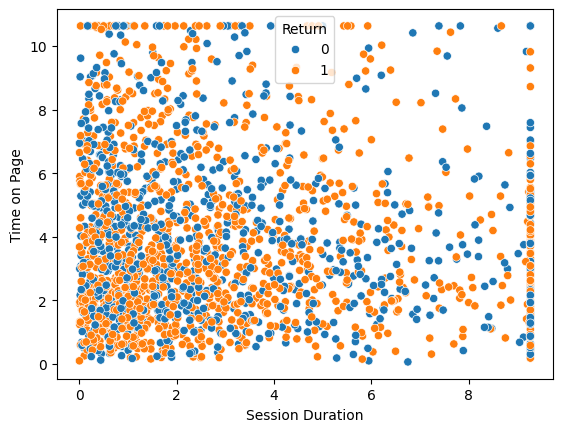

In [6]:
sns.scatterplot(x=df['Session Duration'], y=df['Time on Page'], hue=df['Return'])

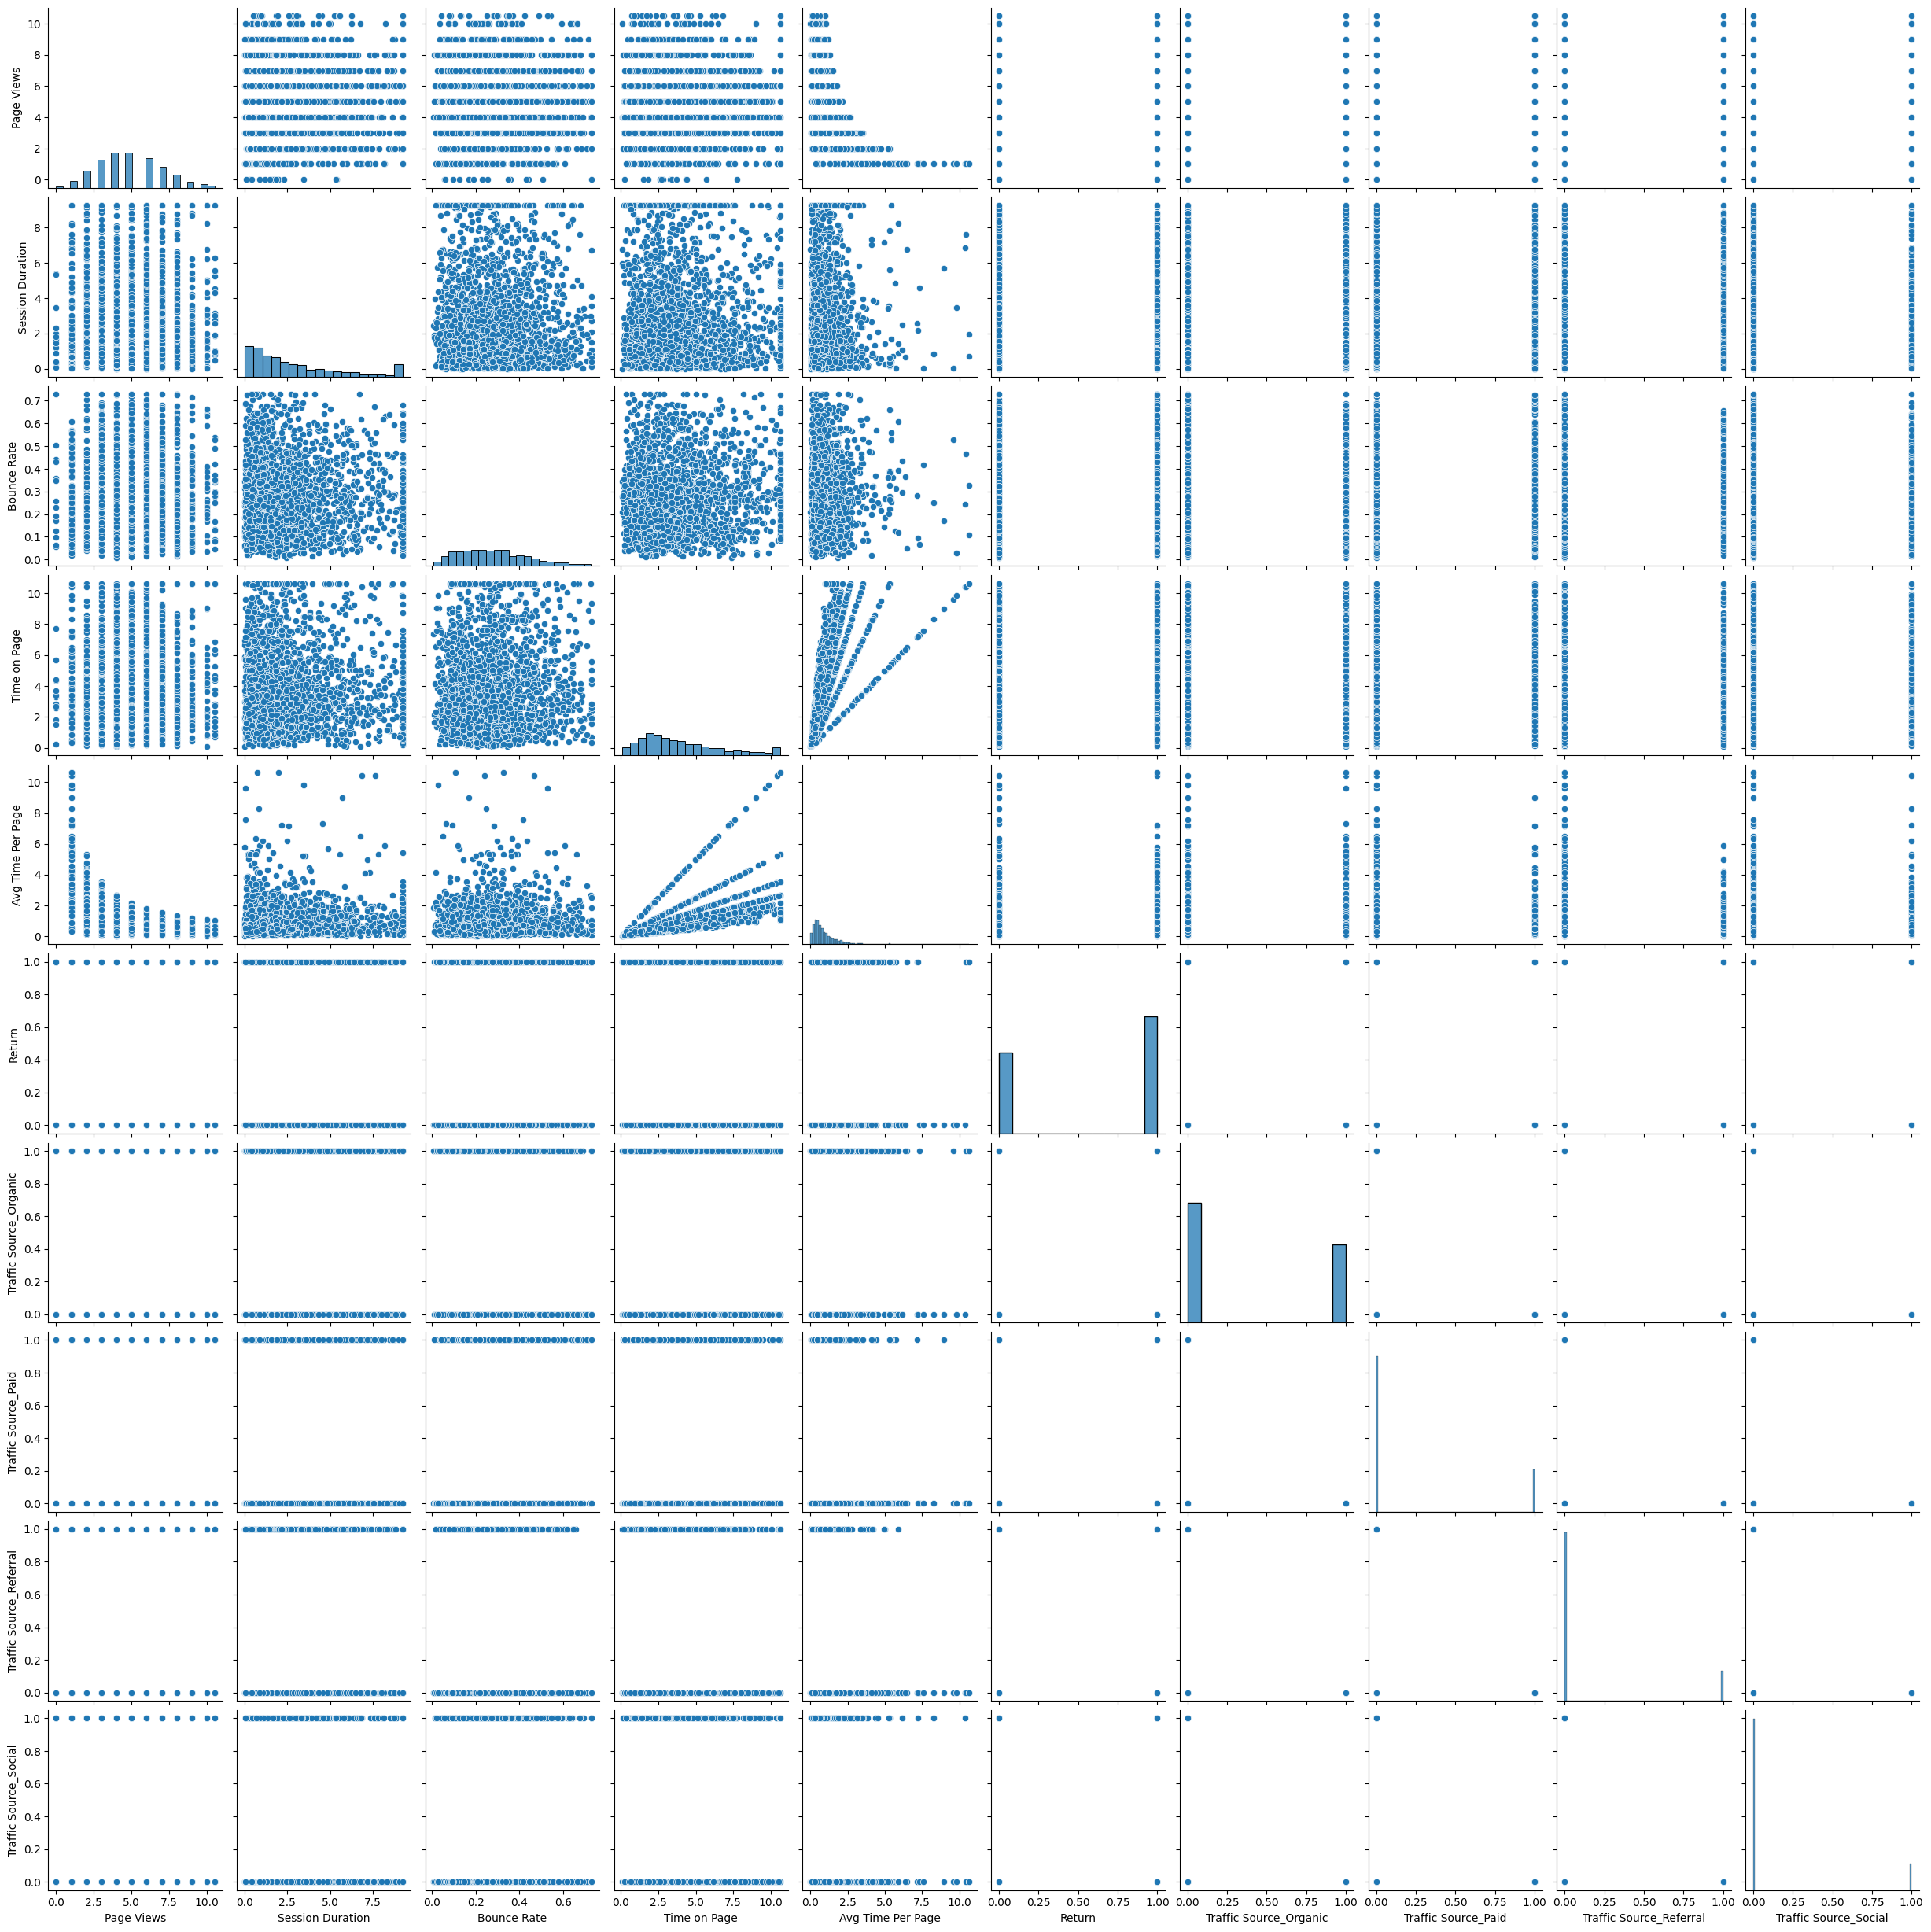

In [24]:
sns.pairplot(df)

In [23]:
#step1--split the data 
X = df.drop("Return", axis=1)
y = df["Return"]

In [24]:
#step--train/test/split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2,random_state=42)

In [25]:
X_train.shape

(1600, 6)

In [26]:
y_train.shape

(1600,)

In [27]:
#one hot encoding 
trf1 =  ColumnTransformer ([('Traffic Source',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),[2])],remainder='passthought')

In [28]:
#scaling 
trf2 = ColumnTransformer([('scale',StandardScaler(),slice(0,11))])  #0 include 11 exclude

In [ ]:
# train the model
trf5 = DecisionTreeClassifier()